In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [51]:
# 1. Ingesti Data
df = pd.read_csv('telco_churn_clean.csv')
df.columns = df.columns.str.lower()
# Paksa konversi kolom total_charges ke numerik (mengubah spasi kosong menjadi NaN)
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# Injeksi logika bisnis: Isi NaN dengan angka 0
df['totalcharges'] = df['totalcharges'].fillna(0)

# 2. Isolasi Target dan Noise
# Kita mendefinisikan 'churn_binary' sebagai target prediksi absolut (y)
y = df['churn_binary']

# Menghapus identifier unik, label kategorial target, dan label biner target dari matriks fitur
X = df.drop(columns=['customerid', 'churn', 'churn_binary'])

# 3. Transformasi Biner (One-Hot Encoding)
# Parameter drop_first=True adalah protokol wajib untuk mencegah Multikolinearitas
X_encoded = pd.get_dummies(X, drop_first=True)

# 4. Validasi Dimensi
print(f"Dimensi awal dataset fitur (X): {X.shape}")
print(f"Dimensi matriks biner ortogonal (X_encoded): {X_encoded.shape}")
df.head()

Dimensi awal dataset fitur (X): (7043, 19)
Dimensi matriks biner ortogonal (X_encoded): (7043, 30)


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [52]:
# 1. Membelah Dimensi Matriks (80% Training, 20% Testing)
# Parameter stratify=y wajib untuk mempertahankan rasio kelas churn yang asimetris
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Inisialisasi Algoritma Normalisasi
scaler = StandardScaler()

# 3. Fit dan Transform pada Training Set
X_train_scaled = scaler.fit_transform(X_train)

# 4. Transform HANYA pada Testing Set 
X_test_scaled = scaler.transform(X_test)

print(f"Dimensi X_train: {X_train_scaled.shape}")
print(f"Dimensi X_test: {X_test_scaled.shape}")

Dimensi X_train: (5634, 30)
Dimensi X_test: (1409, 30)


In [56]:
# 1. Inisialisasi Algoritma
# Parameter max_iter dinaikkan untuk memastikan konvergensi matriks gradien
log_model = LogisticRegression(class_weight="balanced" ,max_iter=1000, random_state=42)

# 2. Eksekusi Pelatihan (Training)
log_model.fit(X_train_scaled, y_train)

# 3. Eksekusi Prediksi pada Area Terisolasi (Testing)
y_pred = log_model.predict(X_test_scaled)

# 4. Evaluasi Metrik Performa
print("=== Matriks Konfusi (Confusion Matrix) ===")
print(confusion_matrix(y_test, y_pred))
print("\n=== Laporan Klasifikasi (Classification Report) ===")
print(classification_report(y_test, y_pred))

=== Matriks Konfusi (Confusion Matrix) ===
[[749 286]
 [ 80 294]]

=== Laporan Klasifikasi (Classification Report) ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [58]:
# 1. Ekstraksi matriks probabilitas
# Kolom indeks 1 berisi skor probabilitas untuk kelas 1 (Churn)
y_prob_mentah = log_model.predict_proba(X_test_scaled)[:, 1]

# 2. Arsitektur Filter Manual (Threshold = 0.4)
threshold_custom = 0.4

# Jika probabilitas >= 0.4, jadikan 1 (Churn), sisanya 0
y_pred_04 = (y_prob_mentah >= threshold_custom).astype(int)

# 3. Evaluasi Matriks Konfusi Baru
print("=== Matriks Konfusi (Threshold 0.4) ===")
print(confusion_matrix(y_test, y_pred_04))
print("\n=== Laporan Klasifikasi (Threshold 0.4) ===")
print(classification_report(y_test, y_pred_04))

=== Matriks Konfusi (Threshold 0.4) ===
[[662 373]
 [ 50 324]]

=== Laporan Klasifikasi (Threshold 0.4) ===
              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1035
           1       0.46      0.87      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.72      1409



In [ ]:
# 1. Injeksi data aktual (y_test) ke dalam DataFrame evaluasi
# Menggunakan .values untuk mengabaikan potensi perbedaan indeks bauran
df_eval['actual_churn'] = y_test.values

# 2. Hubungkan kembali dengan df_action untuk memperbarui kolom data
df_action = df_eval[df_eval['predicted_churn_04'] == 1].copy()
df_action['intervention_strategy'] = df_action['churn_probability'].apply(route_intervention)

# 3. Isolasi data khusus Tier 1
df_tier_1 = df_action[df_action['intervention_strategy'] == 'Tier 1 - High Risk (Telepon & Diskon Maksimal)'].copy()

# 4. Cetak bauran asli (TP vs FP) di dalam Tier 1
print("=== Distribusi Riwayat Aktual di Tier 1 ===")
# Label 1 mencerminkan TP (Aktual Churn), Label 0 mencerminkan FP (Aktual Setia)
print(df_tier_1['actual_churn'].value_counts())

# 5. Menampilkan sampel data mentah untuk inspeksi visual
# Memilih kolom probabilitas, status aktual, dan beberapa fitur awal
kolom_sampel = ['churn_probability', 'actual_churn'] + [col for col in X_test.columns[:4]]
print("\n=== Sampel 5 Data Teratas di Tier 1 ===")
print(df_tier_1[kolom_sampel].head())

=== Distribusi Riwayat Aktual di Tier 1 ===
actual_churn
1    225
0    151
Name: count, dtype: int64

=== Sampel 5 Data Teratas di Tier 1 ===
      churn_probability  actual_churn  seniorcitizen  tenure  monthlycharges  \
2280           0.851640             0              1       8          100.15   
5748           0.805352             0              0      21           99.85   
3524           0.853187             1              1      11           84.80   
2136           0.818309             0              0      15           91.00   
6529           0.865632             1              1       2           74.85   

      totalcharges  
2280        908.55  
5748       1992.55  
3524        906.85  
2136       1430.05  
6529        156.40  


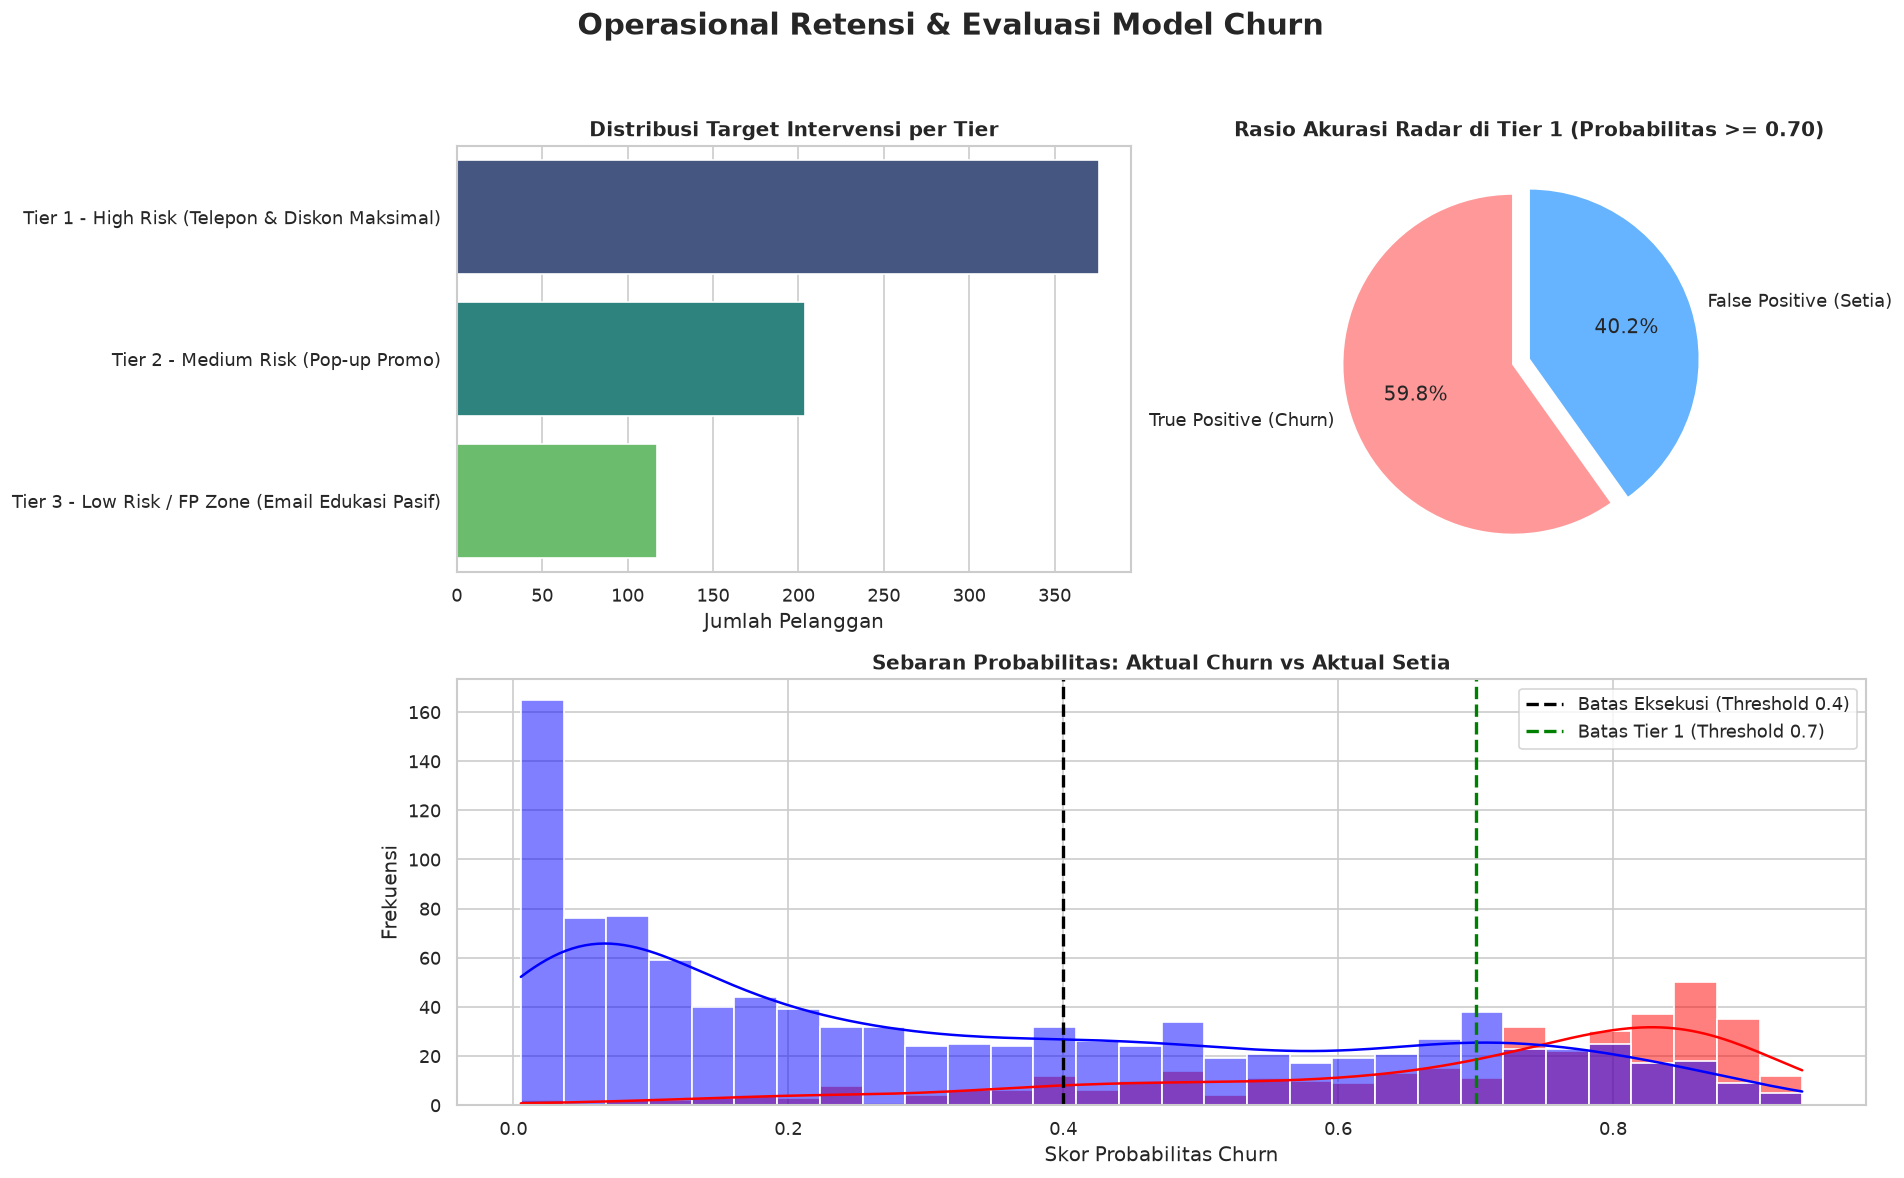

In [67]:
# Konfigurasi parameter visual dasar
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Operasional Retensi & Evaluasi Model Churn', fontsize=18, fontweight='bold', y=0.98)

# Mengatur tata letak grid (2 baris, 2 kolom)
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 2, (3, 4)) # Menggabungkan kolom di baris bawah untuk grafik rentang panjang

# ==========================================
# KOMPONEN 1: Distribusi Beban Kerja (Tier)
# ==========================================
sns.countplot(
    data=df_action, 
    y='intervention_strategy', 
    hue='intervention_strategy',
    order=df_action['intervention_strategy'].value_counts().index, 
    palette='viridis', 
    legend=False,
    ax=ax1
)
ax1.set_title('Distribusi Target Intervensi per Tier', fontweight='bold')
ax1.set_xlabel('Jumlah Pelanggan')
ax1.set_ylabel('')

# ==========================================
# KOMPONEN 2: Audit Kualitas Tier 1 (TP vs FP)
# ==========================================
# Menghitung rasio aktual di Tier 1
tier1_counts = df_tier_1['actual_churn'].value_counts()
labels = ['True Positive (Churn)', 'False Positive (Setia)']
colors = ['#ff9999','#66b3ff']

ax2.pie(
    tier1_counts, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=90, 
    explode=(0.1, 0) # Menyoroti bagian TP
)
ax2.set_title('Rasio Akurasi Radar di Tier 1 (Probabilitas >= 0.70)', fontweight='bold')

# ==========================================
# KOMPONEN 3: Peta Distribusi Probabilitas Mentah
# ==========================================
sns.histplot(
    data=df_eval, 
    x='churn_probability', 
    hue='actual_churn', 
    bins=30, 
    kde=True, 
    palette={0: 'blue', 1: 'red'}, 
    alpha=0.5,
    ax=ax3
)
ax3.axvline(x=0.4, color='black', linestyle='--', linewidth=2, label='Batas Eksekusi (Threshold 0.4)')
ax3.axvline(x=0.7, color='green', linestyle='--', linewidth=2, label='Batas Tier 1 (Threshold 0.7)')
ax3.set_title('Sebaran Probabilitas: Aktual Churn vs Aktual Setia', fontweight='bold')
ax3.set_xlabel('Skor Probabilitas Churn')
ax3.set_ylabel('Frekuensi')
ax3.legend()

# Merapikan jarak antar grafik
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [65]:
# ==========================================================
# REKAYASA 1: RESTORASI IDENTIFIER (CUSTOMER ID) VIA INDEX
# ==========================================================
# Menyalin matriks X_test untuk keperluan evaluasi operasional
df_eval = X_test.copy()

# Menarik kembali customerid asli berdasarkan sinkronisasi indeks
df_eval['customer_id'] = df.loc[X_test.index, 'customerid']

# ==========================================================
# EVALUASI PROBABILITAS (THRESHOLD 0.4)
# ==========================================================
# Pastikan menggunakan nama variabel modelmu yang aktif: 'log_model'
y_prob_mentah = log_model.predict_proba(X_test_scaled)[:, 1]
y_pred_04 = (y_prob_mentah >= 0.4).astype(int)

df_eval['churn_probability'] = y_prob_mentah
df_eval['predicted_churn_04'] = y_pred_04
df_eval['actual_churn'] = y_test.values

# Isolasi data: Hanya mengambil pelanggan yang terdeteksi masuk radar Churn (Label 1)
df_action = df_eval[df_eval['predicted_churn_04'] == 1].copy()

# Aturan Alur Strategi (Routing Function)
def route_intervention(prob):
    if prob >= 0.70:
        return 'Tier 1 - High Risk (Telepon & Diskon Maksimal)'
    elif prob >= 0.50:
        return 'Tier 2 - Medium Risk (Pop-up Promo)'
    else:
        return 'Tier 3 - Low Risk / FP Zone (Email Edukasi Pasif)'

df_action['intervention_strategy'] = df_action['churn_probability'].apply(route_intervention)

# ==========================================================
# REKAYASA 2: PEMETAAN FILE EKSPLISIT (ANTI-SLASH ERROR)
# ==========================================================
# Menggunakan kamus statis untuk menghindari manipulasi string yang rentan eror OS
file_mapping = {
    'Tier 1 - High Risk (Telepon & Diskon Maksimal)': 'tier_1_high_risk.csv',
    'Tier 2 - Medium Risk (Pop-up Promo)': 'tier_2_medium_risk.csv',
    'Tier 3 - Low Risk / FP Zone (Email Edukasi Pasif)': 'tier_3_low_risk_fp_zone.csv'
}

# Menyusun urutan kolom agar customer_id berada di paling kiri (memudahkan tim operasional)
kolom_meta = ['customer_id', 'churn_probability', 'actual_churn', 'intervention_strategy']
kolom_fitur = [col for col in df_action.columns if col not in kolom_meta + ['predicted_churn_04']]
kolom_final = kolom_meta + kolom_fitur

# Eksekusi Ekspor Loop Aman
for tier_name, data_terpisah in df_action.groupby('intervention_strategy'):
    # Mengambil nama file yang aman dari kamus pemetaan
    clean_filename = file_mapping.get(tier_name, 'tier_unknown.csv')
    
    # Ekspor sub-matriks dengan susunan kolom yang sudah dioptimasi
    data_terpisah[kolom_final].to_csv(clean_filename, index=False)
    print(f"File [{clean_filename}] berhasil diekspor. Total baris: {len(data_terpisah)}")

File [tier_1_high_risk.csv] berhasil diekspor. Total baris: 376
File [tier_2_medium_risk.csv] berhasil diekspor. Total baris: 204
File [tier_3_low_risk_fp_zone.csv] berhasil diekspor. Total baris: 117
